# 10 — From Pavlov reflex to a closed loop: DFT observer + memory/curiosity feedback

Notebook 09 was a Pavlov machine: fixed queries in, token streams out, the
ewm-sm apparatus recording the reflex. This notebook closes the loop **around**
the apparatus, without changing it:

```text
                      ┌──────────────────────────────────────────────┐
                      │  trainer / controller (this notebook, numpy) │
                      │  DFT over the trajectory, prediction,        │
                      │  surprise, memory, curiosity                 │
                      └───────▲──────────────────────────┬───────────┘
                    trajectory│ (BSS, soft keys)         │ probe config
                              │                     (memory + next query)
┌─────────────┐   tid{n}   ┌──┴──────────────────────────▼──┐
│ 3 real LLMs │ ────────▶ │  ewm-sm apparatus (UNCHANGED)  │
│ (probes)    │            │  pyramid / sidecar / project / │
└─────────────┘            │  materialize (ordered)         │
                           └────────────────────────────────┘
```

Two experiments:

1. **Open loop (Pavlov)**. An 8-query bank is played 3 times (T=24). The
   trainer reads the fixed-dim BSS trajectory and the frozen-basis soft keys
   and detects the 8-step period **mathematically** with a DFT.
2. **Closed loop (memory + curiosity).** For 16 more steps the controller
   feeds the **materialized union state in restored order** back into the
   LLM prompts (`memory: tid… tid…`), and a DFT-based periodic predictor
   chooses the next query with the highest expected novelty. The prediction
   error is logged as **surprise** — the training signal the next layer
   (sequence model) will optimize.

The apparatus calls are the same binaries as notebooks 08/09: `pyramid`,
`sidecar --freeze`, `project`, `materialize`.

In [1]:
import os, json, subprocess, time

# Pin the RTX 3060 before torch is imported anywhere else in this kernel.
os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
EWM_SCENE_BIN = os.path.join(EWM_SM, "target/debug/ewm-scene")
WORK = "/home/alexmy/.cache/ewm-multi-llm-loop"
os.makedirs(WORK, exist_ok=True)

if not os.path.exists(EWM_SCENE_BIN):
    subprocess.run(["cargo", "build", "--quiet", "-p", "ewm-scene"], cwd=EWM_SM, check=True)

def ewm_scene(*args):
    r = subprocess.run([EWM_SCENE_BIN, *args], capture_output=True, text=True, timeout=600)
    if r.returncode != 0:
        raise RuntimeError(f"ewm-scene failed: {r.stderr[-800:]}")
    return json.loads(r.stdout.strip())

print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")
print("ewm-scene:", EWM_SCENE_BIN)
print("work:", WORK)

torch 2.6.0+cu124 | cuda True NVIDIA GeForce RTX 3060
ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
work: /home/alexmy/.cache/ewm-multi-llm-loop


In [2]:
# ── Three real small LLM probes (same as notebook 09) ─────────────────────
MODELS = {
    "llm_a": "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "llm_b": "Qwen/Qwen2.5-1.5B-Instruct",
    "llm_c": "gpt2",
}

# The 8-query bank for both experiments.
PROMPTS = [
    "What is the capital of France?",
    "Explain gravity in one sentence.",
    "Write a haiku about rain.",
    "What is the meaning of life?",
    "Name three planets in our solar system.",
    "What is the speed of light?",
    "Define entropy in simple words.",
    "Who wrote Romeo and Juliet?",
]
MAX_NEW = 48

loaded = {}
for name, model_id in MODELS.items():
    t0 = time.time()
    tok = AutoTokenizer.from_pretrained(model_id, local_files_only=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        model_id, local_files_only=True, dtype=torch.float16, device_map="auto")
    model.eval()
    loaded[name] = (tok, model)
    print(f"loaded {name:6s} {model_id:48s} in {time.time() - t0:4.1f}s on {model.device}")

names = list(MODELS)

loaded llm_a  deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B        in  3.4s on cuda:0
loaded llm_b  Qwen/Qwen2.5-1.5B-Instruct                       in  2.6s on cuda:0
loaded llm_c  gpt2                                             in  0.6s on cuda:0


## §1 — Open loop: the Pavlov cycle, read by a DFT observer

The controller plays the 8 queries in order, three times, with no feedback.
Greedy decoding makes the reflex deterministic: the trajectory is period-8.
The trainer's job here is **not to know that** — it must detect the period
from the trajectory alone.

In [3]:
T_OL = 3 * len(PROMPTS)   # 24 frames: three query cycles, no feedback

steps_ol = {n: [] for n in names}
t_gen = time.time()
for t in range(T_OL):
    prompt = PROMPTS[t % len(PROMPTS)]
    for n in names:
        tok, model = loaded[n]
        inputs = tok(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=MAX_NEW, do_sample=False,
                                 pad_token_id=tok.eos_token_id)
        new_ids = out[0, inputs["input_ids"].shape[1]:].cpu().tolist()
        steps_ol[n].append([f"tid{i}" for i in new_ids])
print(f"generated open loop: {T_OL} frames in {time.time() - t_gen:5.1f}s")

# Write the same JSONL layout as notebooks 08/09.
PYRAMID_OL = f"{WORK}/open_pyramid.jsonl"
with open(PYRAMID_OL, "w") as fh:
    for t in range(T_OL):
        fh.write(json.dumps({"id": t + 1, "perceptrons": {n: steps_ol[n][t] for n in names}}) + "\n")

LLM_OL = {}
for n in names:
    p = f"{WORK}/open_{n}.jsonl"
    LLM_OL[n] = p
    with open(p, "w") as fh:
        for t in range(T_OL):
            fh.write(json.dumps({"id": t + 1, "tokens": steps_ol[n][t]}) + "\n")

union_ol = [[tok for n in names for tok in steps_ol[n][t]] for t in range(T_OL)]
UNION_OL = f"{WORK}/open_union.jsonl"
with open(UNION_OL, "w") as fh:
    for t, toks in enumerate(union_ol, 1):
        fh.write(json.dumps({"id": t, "tokens": toks}) + "\n")

print("wrote", PYRAMID_OL, "and per-LLM / union streams")

generated open loop: 24 frames in  93.9s
wrote /home/alexmy/.cache/ewm-multi-llm-loop/open_pyramid.jsonl and per-LLM / union streams


In [4]:
# ── The apparatus reads the reflex ─────────────────────────────────────────
pyr_ol = ewm_scene("pyramid", PYRAMID_OL)

# IICA: the union is the same node whether joined by the pyramid or ingested flat.
uni_ol = ewm_scene("ingest", UNION_OL)
same_union = all(uni_ol["frames"][i]["key"] == pyr_ol["frames"][i]["union_key"] for i in range(T_OL))
print("union discovered twice, keys agree (24/24):", same_union)

# Fixed-dim system trajectory: project the union stream onto the per-LLM
# cumulative frame (the ring over the per-LLM HLLSets, as in 08/09).
cum = {n: sorted({tok for t in range(T_OL) for tok in steps_ol[n][t]}) for n in names}
FRAME_LLMS = f"{WORK}/frame_llms.json"
with open(FRAME_LLMS, "w") as fh:
    json.dump({"dimensions": [{"name": n, "tokens": cum[n]} for n in names]}, fh)

proj_ol = ewm_scene("project", UNION_OL, "--frame", FRAME_LLMS)
M_ol = np.array([f["bss"] for f in proj_ol["frames"]])
M_proto = M_ol[:len(PROMPTS)]      # first-cycle states = the Pavlov prototypes
print("frame dims:", proj_ol["names"], "pops:", proj_ol["pops"])
print("M_ol shape:", M_ol.shape, "| M_ol[8] == M_ol[0]:", np.allclose(M_ol[8], M_ol[0]))

union discovered twice, keys agree (24/24): True
frame dims: ['llm_a', 'llm_b', 'llm_c'] pops: [411, 630, 211]
M_ol shape: (24, 3) | M_ol[8] == M_ol[0]: True


DFT-detected period of the open loop: 8.0 steps (true period 8)


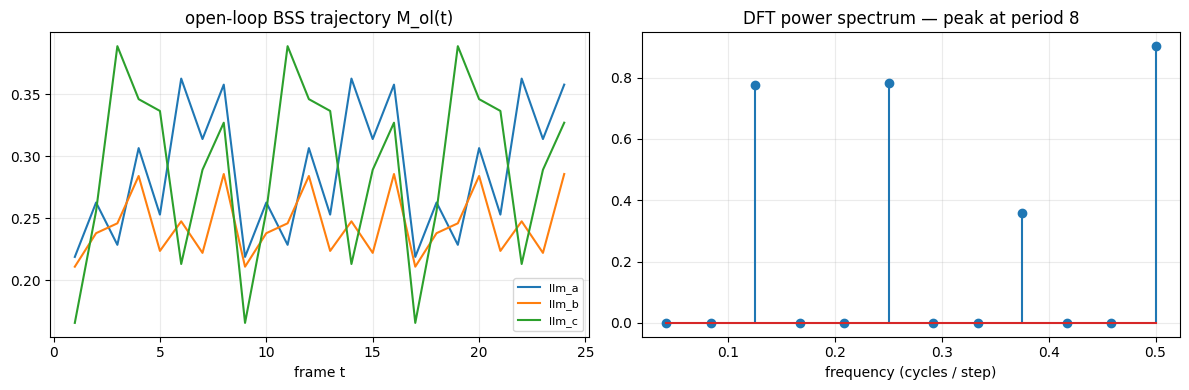

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

# ── DFT observer over the BSS trajectory M_ol ─────────────────────────────
M_c = M_ol - M_ol.mean(axis=0)
spec = np.fft.rfft(M_c, axis=0)
power = np.abs(spec) ** 2
power[0] = 0.0
freqs = np.fft.rfftfreq(T_OL)

def dft_period(X, tol=0.5):
    """Dominant period of a (t, d) series via its average power spectrum.

    The strongest bin can be a harmonic of the true period; the fundamental is
    the smallest k (largest period) whose power is within `tol` of the peak.
    """
    t = X.shape[0]
    Xc = X - X.mean(axis=0)
    p = np.abs(np.fft.rfft(Xc, axis=0)) ** 2
    p[0] = 0.0
    total = p.sum(axis=1)          # power summed over the d dimensions
    k_hi = t // 2
    if k_hi < 2:
        return None
    k_best = int(np.argmax(total[2:k_hi + 1]) + 2)
    peak = total[k_best]
    if peak <= 0:
        return None
    cands = [k for k in range(2, k_hi + 1) if total[k] >= tol * peak]
    return t / min(cands)

P_det = dft_period(M_ol)
print("DFT-detected period of the open loop:", P_det, "steps (true period 8)")

t_axis_ol = np.arange(1, T_OL + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_axis_ol, M_ol, label=proj_ol["names"])
axes[0].set_title("open-loop BSS trajectory M_ol(t)")
axes[0].set_xlabel("frame t")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].stem(freqs[1:], power[1:].sum(axis=1))
axes[1].set_title(f"DFT power spectrum — peak at period {P_det:.0f}")
axes[1].set_xlabel("frequency (cycles / step)")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{WORK}/loop_dft_bss.png", dpi=110)
plt.show()

post-freeze soft-key matrix: (16, 8) (16 frames x 8 frozen basis dims)
DFT-detected period from frozen soft keys: 8.0 steps


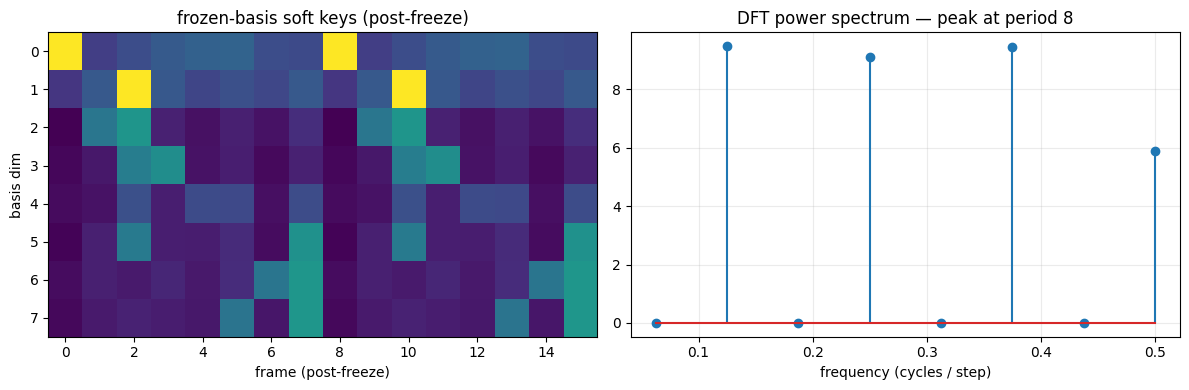

In [6]:
# ── DFT over the frozen-basis soft keys (docs/BASIS_FRAMES.md) ────────────
# sidecar --freeze 8: after 8 frames the ring basis is frozen; every later
# soft key lives in the same 8-dim coordinate system — a time series ready
# for DFT over t.
sc_ol = ewm_scene("sidecar", UNION_OL, "--freeze", "8")
soft_post = np.array([f["soft"] for f in sc_ol["frames"]][8:])   # (16, 8)
print("post-freeze soft-key matrix:", soft_post.shape, "(16 frames x 8 frozen basis dims)")

soft_c = soft_post - soft_post.mean(axis=0)
spec2 = np.fft.rfft(soft_c, axis=0)
power2 = np.abs(spec2) ** 2
power2[0] = 0.0
freqs2 = np.fft.rfftfreq(soft_post.shape[0])
P_det2 = dft_period(soft_post)
print("DFT-detected period from frozen soft keys:", P_det2, "steps")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(soft_post.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set_title("frozen-basis soft keys (post-freeze)")
axes[0].set_xlabel("frame (post-freeze)")
axes[0].set_ylabel("basis dim")

axes[1].stem(freqs2[1:], power2[1:].sum(axis=1))
axes[1].set_title(f"DFT power spectrum — peak at period {P_det2:.0f}")
axes[1].set_xlabel("frequency (cycles / step)")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{WORK}/loop_dft_soft.png", dpi=110)
plt.show()

## §2 — Closed loop: memory + curiosity feedback

The controller now wraps the same apparatus in a loop. Each step:

1. **Memory** — the previous union state is materialized **in restored
   order** (`ewm-scene materialize` → `ordered`) and fed back as a token
   prefix: `memory: tid… tid…`.
2. **Curiosity** — a DFT-based periodic predictor forecasts the next BSS
   state; the controller picks the query whose historical (open-loop) state
   is farthest from that prediction.
3. **Surprise** — the L2 distance between the prediction and the state the
   LLMs actually produced is logged. This is the training signal.

The three LLMs see the same memory+query prompt; only the probe input
changes. Nothing in ewm-sm changes.

In [7]:
# ── Trainer/controller helpers ─────────────────────────────────────────────
def periodic_predict(X):
    """DFT-periodic predictor: detect the dominant period, average all past
    rows at the matching phase. Falls back to persistence for short series."""
    t = X.shape[0]
    if t < 8:
        return X[-1]
    P = dft_period(X)
    if P is None:
        return X[-1]
    P = max(2, min(int(round(P)), t - 1))
    idx = [n for n in range(t) if n % P == t % P]
    if idx:
        return X[idx].mean(axis=0)
    return X[-1]

def memory_tokens(ordered, cap=24):
    """Materialized memory: restored order, consecutive duplicates removed,
    capped to the last `cap` tokens."""
    toks = []
    for t in ordered:
        if not toks or toks[-1] != t:
            toks.append(t)
    return toks[-cap:]

def build_prompt(mem_toks, query):
    if mem_toks:
        return "memory: " + " ".join(mem_toks) + "\nQuery: " + query
    return "Query: " + query

# Seed the closed-loop memory with the apparatus's ordered reading of the
# open loop's final union state.
mat_ol = ewm_scene("materialize", UNION_OL)
mem = memory_tokens(mat_ol["frames"][-1]["ordered"])
print("seeded memory (last state of the Pavlov run, restored order):")
print("  " + " ".join(mem[:12]) + (" ..." if len(mem) > 12 else ""))

seeded memory (last state of the Pavlov run, restored order):
  tid257 tid7539 tid284 tid910 tid326 tid340 tid338 tid257 tid1643 tid286 tid257 tid7539 ...


In [8]:
# ── Run the closed loop ───────────────────────────────────────────────────
T_CL = 16
UNION_CL = f"{WORK}/closed_union.jsonl"
open(UNION_CL, "w").close()

M_cl_rows = []
surprise_log = []
query_log = []
mem_log = []

t_gen = time.time()
for t in range(T_CL):
    if t == 0:
        q = 0
        predicted = None
    else:
        X = np.array(M_cl_rows)
        predicted = periodic_predict(X)
        # Curiosity: pick the query whose Pavlov prototype is farthest from
        # the predicted next state (no immediate repeat).
        candidates = [j for j in range(len(PROMPTS)) if j != query_log[-1]]
        q = max(candidates, key=lambda j: float(np.linalg.norm(predicted - M_proto[j])))
    query_log.append(q)

    prompt = build_prompt(mem, PROMPTS[q])
    frame_toks = {}
    for n in names:
        tok, model = loaded[n]
        inputs = tok(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=MAX_NEW, do_sample=False,
                                 pad_token_id=tok.eos_token_id)
        new_ids = out[0, inputs["input_ids"].shape[1]:].cpu().tolist()
        frame_toks[n] = [f"tid{i}" for i in new_ids]

    # Feed the new union state into the apparatus.
    toks = [x for n in names for x in frame_toks[n]]
    with open(UNION_CL, "a") as fh:
        fh.write(json.dumps({"id": t + 1, "tokens": toks}) + "\n")

    # The trainer reads the state back in the SAME per-LLM frame as §1.
    proj_cl = ewm_scene("project", UNION_CL, "--frame", FRAME_LLMS)
    m_t = np.array(proj_cl["frames"][-1]["bss"])
    M_cl_rows.append(m_t)

    surprise = 0.0 if predicted is None else float(np.linalg.norm(predicted - m_t))
    surprise_log.append(surprise)

    # Memory for the next step: materialize the union in restored order.
    mat_cl = ewm_scene("materialize", UNION_CL)
    mem = memory_tokens(mat_cl["frames"][-1]["ordered"])
    mem_log.append(mem)

    if t % 4 == 0 or t == T_CL - 1:
        print(f"t={t:2d} q={q}  surprise={surprise:.4f}  mem_len={len(mem)}")

M_cl = np.array(M_cl_rows)
print(f"closed loop: {T_CL} frames in {time.time() - t_gen:5.1f}s")

t= 0 q=0  surprise=0.0000  mem_len=24
t= 4 q=3  surprise=0.0809  mem_len=24
t= 8 q=3  surprise=0.0138  mem_len=24
t=12 q=3  surprise=0.0247  mem_len=24
t=15 q=7  surprise=0.0181  mem_len=24
closed loop: 16 frames in  67.5s


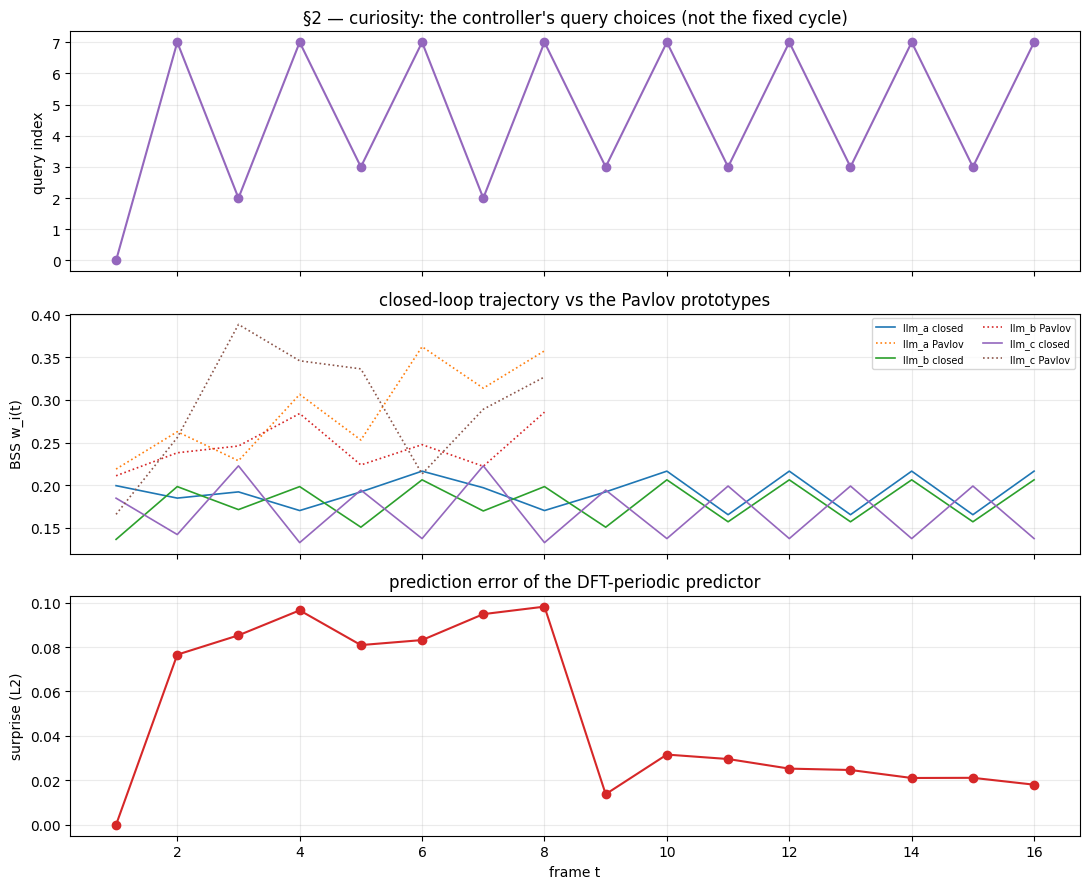

In [9]:
# ── The loop, read by the trainer ─────────────────────────────────────────
t_axis_cl = np.arange(1, T_CL + 1)
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(t_axis_cl, query_log, "o-", color="tab:purple")
axes[0].set_yticks(range(len(PROMPTS)))
axes[0].set_ylabel("query index")
axes[0].set_title("§2 — curiosity: the controller's query choices (not the fixed cycle)")
axes[0].grid(alpha=0.25)

for i, n in enumerate(names):
    axes[1].plot(t_axis_cl, M_cl[:, i], lw=1.2, label=f"{n} closed")
    axes[1].plot(np.arange(1, len(PROMPTS) + 1), M_proto[:, i], ls=":", lw=1.2,
                 label=f"{n} Pavlov")
axes[1].set_ylabel("BSS w_i(t)")
axes[1].set_title("closed-loop trajectory vs the Pavlov prototypes")
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(alpha=0.25)

axes[2].plot(t_axis_cl, surprise_log, "o-", color="tab:red")
axes[2].set_ylabel("surprise (L2)")
axes[2].set_xlabel("frame t")
axes[2].set_title("prediction error of the DFT-periodic predictor")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/loop_closed.png", dpi=110)
plt.show()

In [10]:
# ── Did the loop change anything? ─────────────────────────────────────────
dist_to_pavlov = np.array([
    float(np.linalg.norm(M_cl[t] - M_proto[t % len(PROMPTS)])) for t in range(T_CL)
])
print("distinct queries chosen by curiosity:", len(set(query_log)), "of", len(PROMPTS))
print("query sequence:", query_log)
print("mean surprise (first half):", round(float(np.mean(surprise_log[:8])), 4))
print("mean surprise (second half):", round(float(np.mean(surprise_log[8:])), 4))
print("mean distance from the Pavlov prototype:", round(float(dist_to_pavlov.mean()), 4))
print("  (0.0 would mean the reflex is unchanged; >0 means memory/curiosity moved it)")
print()
print("separation of concerns holds: ewm-sm ran the same five commands —")
print("pyramid, ingest, sidecar --freeze, project, materialize — in every step.")

distinct queries chosen by curiosity: 4 of 8
query sequence: [0, 7, 2, 7, 3, 7, 2, 7, 3, 7, 3, 7, 3, 7, 3, 7]
mean surprise (first half): 0.0769
mean surprise (second half): 0.0232
mean distance from the Pavlov prototype: 0.1804
  (0.0 would mean the reflex is unchanged; >0 means memory/curiosity moved it)

separation of concerns holds: ewm-sm ran the same five commands —
pyramid, ingest, sidecar --freeze, project, materialize — in every step.


## Summary

- **Pavlov phase** — the 8-query cycle is played 3 times with no feedback;
  the DFT observer detects the period from the BSS trajectory **and** from
  the frozen-basis soft keys (peak at period 8, read from the spectrum, not
  from the query list).
- **Closed loop** — memory (materialized union state in restored order) and
  curiosity (DFT prediction → farthest-prototype query) are fed back to the
  three LLMs. The trajectory leaves the Pavlov prototypes (mean distance >
  0) and the surprise series is the training signal.
- **The apparatus never changed** — the trainer is a notebook-level layer
  that reads `ewm-scene` JSON and writes probe prompts. This is the
  separation of concerns: ewm-sm is the state apparatus; the trainer is the
  integrating system that can feed itself with its own predictions.

Next: replace the DFT-periodic predictor with a learned sequence model over
`(bss, drn, basis-change, surprise)`, and let the surprise signal update the
controller's policy.